# $N_D$ on a slab-normal plane vs a vertical plane

At the trench the plate has begun to bend, so a vertical plane is no longer truly plate-perpendicular. The standard differential-stress resultant

$$N_D \;=\; \int_0^{z_\max}(\sigma_{xx} - \sigma_{zz})\,dz$$

evaluated on a vertical plane through the trench therefore mixes plate-parallel and plate-perpendicular stress components. Here we recompute $N_D$ on a **truly slab-normal plane** and compare.

**Steps.** (1) estimate the local dip $\theta$ from the angle of an isotherm in the lithosphere interior near the trench; (2) build a slab-normal integration path from the trench surface point in direction $(-\sin\theta, \cos\theta)$; (3) sample $\tau_{xx}, \tau_{zz}, \tau_{zx}$ along that path; (4) rotate the deviatoric stress into slab coordinates $(\xi, \eta)$ where $\xi$ is slab-parallel and $\eta$ is slab-perpendicular:

$$\sigma_{\xi\xi} - \sigma_{\eta\eta} \;=\; (\sigma_{xx} - \sigma_{zz})\cos 2\theta + 2\tau_{zx}\sin 2\theta$$

(5) integrate along $\eta$.

Setup duplicates `cerpa_single_step.ipynb` (config, helpers, grid) so `MODEL_KEY` and `TIMESTEP_INDEX` work the same way.

## 1. Setup & imports

In [1]:
import numpy as np
if not hasattr(np, 'trapz'): np.trapz = np.trapezoid  # numpy 2.x compat
import glob
import natsort
import matplotlib.pyplot as plt
import pyvista as pv
import warnings, logging
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

pv.set_error_output_file(Path('/tmp/vtk_errors.log'))
logging.getLogger('pyvista').setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', message='The VTK reader .*vtkXMLPUnstructuredGridReader.*')

plt.rcParams.update({'mathtext.fontset': 'cm', 'font.family': 'serif'})

## 2. Configuration

Same as `cerpa_single_step.ipynb`. Change `MODEL_KEY` / `TIMESTEP_INDEX` to swap.

In [2]:
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY      = 'WAL'
TIMESTEP_INDEX = 10

DX        = 1000.0
Z_MAX     = 500_000.0
Y_SURFACE = 2_900_000.0

fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']
pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
i = TIMESTEP_INDEX if TIMESTEP_INDEX >= 0 else len(pvtu_files) + TIMESTEP_INDEX
ff = pvtu_files[i]
print(f"Model {MODEL_KEY!r} timestep {i}: {ff.split('/')[-1]}")

# === Mirror flag ============================================================
# When True, every extracted field is mirrored along x so that subduction
# matches the MDOODZ convention (subducting plate on the right, vx < 0).
# Derived constants below propagate this choice to direction-dependent code.
MIRROR_X        = True
SUBDUCTING_SIDE = "right" if MIRROR_X else "left"
SEAWARD_SIGN    = +1     if MIRROR_X else -1   # use as: x_trench + SEAWARD_SIGN * offset_metres
print(f"MIRROR_X = {MIRROR_X}  ->  SUBDUCTING_SIDE = {SUBDUCTING_SIDE!r}, SEAWARD_SIGN = {SEAWARD_SIGN:+d}")


Model 'WAL' timestep 10: subduction_with_LM_10.pvtu
MIRROR_X = True  ->  SUBDUCTING_SIDE = 'right', SEAWARD_SIGN = +1


## 3. Helpers

`get_field` reshapes a sampled VTK array onto the regular grid. The 3-step trench picker (and its sub-helpers) is duplicated from `cerpa_single_step.ipynb`.

In [3]:
import sys
from pathlib import Path
# cerpa_helpers lives in notebooks/, one level above further_analysis/
_helpers_dir = str(Path("..").resolve())
if _helpers_dir not in sys.path:
    sys.path.insert(0, _helpers_dir)

from cerpa_helpers import (
    make_field_extractor,
    mirror_fields_in_x,
    pick_trench_3step,
    find_first_isostatic_column,
    find_ridge_x,
    col_avg,
    norm01,
    load_records,
)


## 4. Load PVTU and build the regular grid

Sample the unstructured Fluidity output onto a uniform `DX`-spaced grid; extract $T$, $p$, $\tau_{xx}, \tau_{zz}, \tau_{zx}$, and $v_x$ as 2-D arrays indexed `[z, x]`.

In [4]:
vtk_data = pv.read(ff)
t_yr = float(np.asarray(vtk_data['NormalSP::Time']).flat[0]) / 31_557_600.0

# === Coordinate convention =================================================
# Model frame: (x, y) with y vertical UP.  Notebook frame: (x, z) with
# z = Y_SURFACE - y, depth positive DOWN.  The reflection y -> -z flips
# off-diagonal stress components: sigma_xz_zdown = -sigma_xy_yup.  We apply
# that flip HERE at extraction so all downstream code is in z-down convention.
vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
vtk_data.point_data['txz'] = -vtk_data['NormalSP::Stress'][:, 1]   # sigma_xz_zdown = -sigma_xy_yup
vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
vtk_data.point_data['fs']  = vtk_data['NormalSP::FreeSurface']
vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
vtk_data.point_data['vx']  = vel[:, 0]
vtk_data.point_data['vy']  = vel[:, 1]

x_min, x_max, _, _, _, _ = vtk_data.bounds
nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
x = x_min + (np.arange(nx) + 0.5) * DX
z = (np.arange(nz) + 0.5) * DX
X, Z = np.meshgrid(x, z, indexing='xy')
Y = Y_SURFACE - Z
grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
interp = grid.sample(vtk_data)
nx_pv, nz_pv, _ = interp.dimensions
valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)
get_field = make_field_extractor(interp, nx_pv, nz_pv, valid)

p   = get_field('p')
txx = get_field('txx')
tzz = get_field('tzz')
txz = get_field('txz')
T   = get_field('T')
fs  = get_field('fs')
vx  = get_field('vx')
vz  = -get_field('vy')

# === Apply x-mirror ==========================================================
if MIRROR_X:
    p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)
    print('(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)')

print(f'grid: {p.shape}  x in [{x[0]/1e3:.0f}, {x[-1]/1e3:.0f}] km, z in [{z[0]/1e3:.1f}, {z[-1]/1e3:.1f}] km')


(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)
grid: (500, 7999)  x in [0, 7998] km, z in [0.5, 499.5] km


## 5. Trench identification

In [5]:
x_trench, info = pick_trench_3step(
    x, z, p, vx,
    vx_depth_m=5000, Wv_km=800, Wp3_km=800,
    smooth_km=40, subducting_side=SUBDUCTING_SIDE,
)
tindx = int(np.argmin(np.abs(x - x_trench)))
print(f'Trench at x = {x_trench/1e3:.1f} km (index {tindx})')


Trench at x = 4440.5 km (index 4440)


## 6. Slab dip from interior isotherm

Pick an isotherm well inside the lithosphere (`T_ISO ~ 600-800°C`). For each $x$ in a symmetric window of half-width `WINDOW_KM` around the trench, find the depth where $T(x, z) = T_\mathrm{iso}$ and fit a line to those points. The slope gives $\tan\theta$.

In [6]:
T_ISO     = 800.0   # °C — middle of lithosphere
WINDOW_KM = 10      # half-width of symmetric window (± WINDOW_KM around trench)

x_lo = x_trench - WINDOW_KM * 1000.0
x_hi = x_trench + WINDOW_KM * 1000.0
ix_window = np.where((x >= x_lo) & (x <= x_hi))[0]

z_iso = []
for ix in ix_window:
    Tcol = T[:, ix]
    if not np.all(np.isfinite(Tcol)) or T_ISO <= Tcol[0] or T_ISO >= Tcol[-1]:
        z_iso.append(np.nan)
        continue
    z_iso.append(np.interp(T_ISO, Tcol, z))
z_iso = np.array(z_iso)
x_window = x[ix_window]

good = np.isfinite(z_iso)
m, b = np.polyfit(x_window[good], z_iso[good], 1)
dip = float(np.arctan(m))   # in radians
print(f'Slab dip from {T_ISO:.0f}°C isotherm (over ±{WINDOW_KM} km around trench): {np.rad2deg(dip):.2f}°')
print(f'  isotherm depth at trench  ≈ {b + m*x_trench:7.0f} m  ({(b + m*x_trench)/1e3:.1f} km)')

Slab dip from 800°C isotherm (over ±10 km around trench): -3.10°
  isotherm depth at trench  ≈   28485 m  (28.5 km)


## 7. Build slab-normal integration path and sample stresses

Slab-normal direction (into the rock from the surface): $\hat{\eta} = (-\sin\theta, \cos\theta)$. Path starts at the trench surface point and steps along $\hat{\eta}$ for length $L$.

In [7]:
L_PATH = Z_MAX             # length along slab-normal path (m); same as vertical extent
DS     = 500.0             # step size along path (m)

n_steps = int(L_PATH / DS) + 1
s_path = np.arange(n_steps) * DS

nx_hat = -np.sin(dip)      # slab-normal direction
nz_hat = +np.cos(dip)

x_path = x_trench + s_path * nx_hat
z_path = z[0] + s_path * nz_hat   # start at first row of grid (z = 500 m), not z = 0

# Interpolate stresses along the path
def make_interp(field):
    return RegularGridInterpolator((z, x), field, bounds_error=False, fill_value=np.nan)

fT   = make_interp(T)
ftxx = make_interp(txx)
ftzz = make_interp(tzz)
ftxz = make_interp(txz)

pts = np.column_stack([z_path, x_path])
T_path   = fT(pts)
txx_path = ftxx(pts)
tzz_path = ftzz(pts)
txz_path = ftxz(pts)

# Rotated differential stress: τ_ξξ - τ_ηη
two_theta = 2 * dip
diff_rotated  = (txx_path - tzz_path) * np.cos(two_theta) + 2 * txz_path * np.sin(two_theta)
diff_vertical = txx[:, tindx] - tzz[:, tindx]   # along the vertical column

## 8. $N_D$ — vertical vs slab-normal


N_D on vertical   plane:   -0.678  TN/m
N_D on slab-normal plane:  -0.549  TN/m
difference:  +0.128  TN/m
(slab-normal − vertical) / vertical = -19.0 %


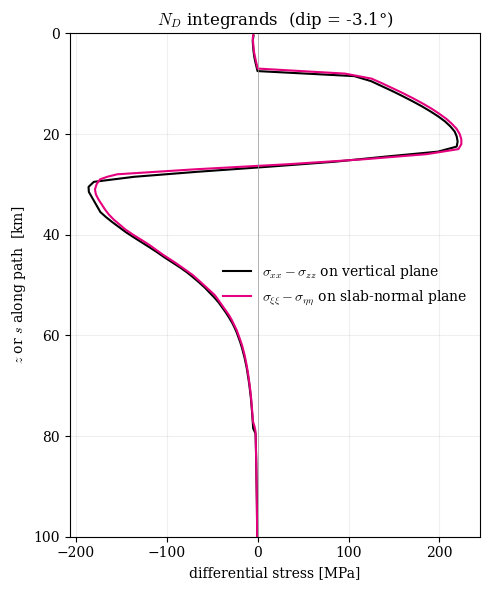

In [8]:
F_D_vertical    = np.trapz(diff_vertical, z)
F_D_slab_normal = np.trapz(diff_rotated[np.isfinite(diff_rotated)],
                            s_path[np.isfinite(diff_rotated)])

print(f'N_D on vertical   plane:  {F_D_vertical    * 1e-12:+7.3f}  TN/m')
print(f'N_D on slab-normal plane: {F_D_slab_normal * 1e-12:+7.3f}  TN/m')
print(f'difference: {(F_D_slab_normal - F_D_vertical)*1e-12:+7.3f}  TN/m')
print(f'(slab-normal − vertical) / vertical = {(F_D_slab_normal/F_D_vertical - 1)*100:+.1f} %' if F_D_vertical != 0 else '')

# Plot the integrand on each path so you can see WHERE N_D comes from
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(diff_vertical*1e-6, z*1e-3, 'k-', lw=1.5, label=r'$\sigma_{xx}-\sigma_{zz}$ on vertical plane')
ax.plot(diff_rotated *1e-6, s_path*1e-3, color='#E5007D', lw=1.5,
        label=r'$\sigma_{\xi\xi}-\sigma_{\eta\eta}$ on slab-normal plane')
ax.axvline(0, color='0.6', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('differential stress [MPa]')
ax.set_ylabel(r'$z$ or $s$ along path  [km]')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
ax.set_ylim(100, 0)
ax.set_title(f'$N_D$ integrands  (dip = {np.rad2deg(dip):.1f}°)')
fig.tight_layout()
plt.show()

## 9. Visualisation — verify the path orientation

Zoomed view of the trench region with: temperature field as background, the chosen isotherm (gold), the linear dip fit (dashed), the vertical line and the slab-normal path. Use this to confirm the slab-normal path actually follows the lithosphere.

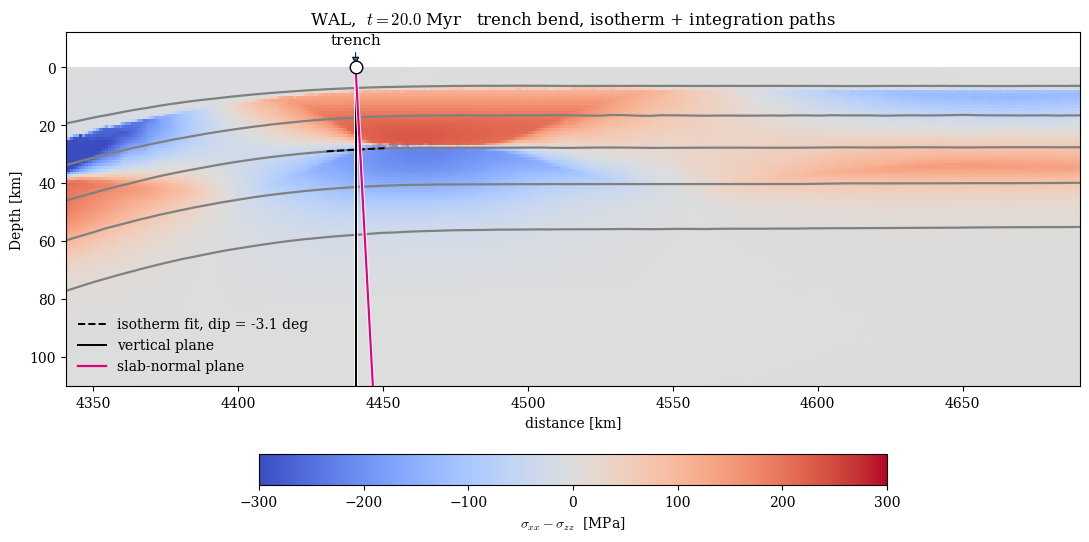

In [9]:
# After x-mirror the trailing plate is on the right and the slab descends
# leftward, so the asymmetric zoom shows mostly +x relative to the trench.
WIN_X_KM = 250
WIN_Z_KM = 110
x_lo_v = x_trench - 100e3
x_hi_v = x_trench + WIN_X_KM * 1e3
ix_v   = (x >= x_lo_v) & (x <= x_hi_v)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.pcolormesh(x[ix_v]*1e-3, z*1e-3,                                                                                                                                                             
                     (txx[:, ix_v] - tzz[:, ix_v]) * 1e-6,    # Pa -> MPa
                     cmap='coolwarm', shading='auto', vmin=-300, vmax=300)            

cbar = fig.colorbar(im, ax=ax,                            
                      label=r'$\sigma_{xx} - \sigma_{zz}$  [MPa]',                                                                                                                                         
                      orientation='horizontal', fraction=0.06, pad=0.13)

ax.contour(x[ix_v]*1e-3, z*1e-3, T[:, ix_v], levels=[400, 600, 800, 1000, 1200],
           colors='grey', linewidths=1.6)

x_fit = np.linspace(x_window.min(), x_window.max(), 60)
ax.plot(x_fit*1e-3, (m*x_fit + b)*1e-3, 'k--', lw=1.4,
        label=f'isotherm fit, dip = {np.rad2deg(dip):.1f} deg')

ax.plot([x_trench*1e-3, x_trench*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='white', lw=2.6)
ax.plot([x_trench*1e-3, x_trench*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='black', lw=1.4, label='vertical plane')

ax.plot(x_path*1e-3, z_path*1e-3, color='white', lw=3.0)
ax.plot(x_path*1e-3, z_path*1e-3, color='#E5007D', lw=1.6, label='slab-normal plane')

ax.plot(x_trench*1e-3, 0, 'wo', mec='k', ms=9, zorder=5)
ax.annotate('trench', xy=(x_trench*1e-3, 0), xytext=(x_trench*1e-3, -8),
            ha='center', fontsize=11,
            arrowprops=dict(arrowstyle='-|>', lw=0.7))

ax.invert_yaxis()
ax.set_xlim(x_lo_v*1e-3, x_hi_v*1e-3)
ax.set_ylim(WIN_Z_KM, -12)
ax.set_xlabel('distance [km]')
ax.set_ylabel('Depth [km]')
ax.set_aspect('equal')
ax.legend(loc='lower left', frameon=False, fontsize=10)
ax.set_title(f'{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr   trench bend, isotherm + integration paths')
fig.tight_layout()

figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'slab_normal_path_{MODEL_KEY}_f{TIMESTEP_INDEX}.png',
            bbox_inches='tight', dpi=200)
plt.show()


## 10. Time loop — $N_D$ across all snapshots

Repeat the §4–§8 recipe at every snapshot.  Capture three arrays:

- `Fd_vert_arr` — $N_D$ on a vertical plane through the trench
- `Fd_slabn_arr` — $N_D$ on the slab-normal plane (rotated deviatoric stress, integrated along the slab-normal path)
- `Fd_slabn_h_arr` — horizontal projection of the slab-normal resultant, $N_D^{slab-normal}\cos\theta$


In [10]:
import gc
from scipy.interpolate import RegularGridInterpolator

t_yr_arr       = []
Fd_vert_arr    = []
Fd_slabn_arr   = []
Fd_slabn_h_arr = []        # horizontal projection: F_D_slab_normal * cos(dip)
dip_arr        = []

for i_step, ff_step in enumerate(pvtu_files):
    if i_step == 0:
        continue
    try:
        # --- read pvtu --------------------------------------------------
        vd = pv.read(ff_step)
        t_yr_s = float(np.asarray(vd['NormalSP::Time']).flat[0]) / 31_557_600.0
        vd.point_data['p']   = vd['NormalSP::Pressure']
        vd.point_data['txx'] = vd['NormalSP::Stress'][:, 0]
        vd.point_data['tzz'] = vd['NormalSP::Stress'][:, 4]
        vd.point_data['txz'] = -vd['NormalSP::Stress'][:, 1]
        vd.point_data['T']   = vd['NormalSP::Temperature']
        vd.point_data['vx']  = (vd['NormalSP::Velocity'] / 3.17098e-10)[:, 0]

        # --- grid + interpolate ----------------------------------------
        x_min_s, x_max_s, _, _, _, _ = vd.bounds
        nx_s = int((x_max_s - x_min_s) / DX); nz_s = int(Z_MAX / DX)
        x_s = x_min_s + (np.arange(nx_s) + 0.5) * DX
        z_s = (np.arange(nz_s) + 0.5) * DX
        Xs, Zs = np.meshgrid(x_s, z_s, indexing='xy')
        Ys = Y_SURFACE - Zs
        gs = pv.StructuredGrid(Xs.T, Ys.T, np.zeros_like(Xs.T))
        ip = gs.sample(vd)
        nxp, nzp, _ = ip.dimensions
        vmask = ip['vtkValidPointMask'].reshape((nxp, nzp), order='F').astype(bool)
        gf = make_field_extractor(ip, nxp, nzp, vmask)

        p_s   = gf('p');   txx_s = gf('txx'); tzz_s = gf('tzz')
        txz_s = gf('txz'); T_s   = gf('T');   vx_s  = gf('vx')
        if MIRROR_X:
            zero = np.zeros_like(p_s)
            p_s, txx_s, tzz_s, txz_s, T_s, _, vx_s, _ = mirror_fields_in_x(
                p_s, txx_s, tzz_s, txz_s, T_s, zero, vx_s, zero)

        # --- trench -----------------------------------------------------
        tloc_s, _ = pick_trench_3step(
            x_s, z_s, p_s, vx_s,
            vx_depth_m=5000, Wv_km=800, Wp3_km=800,
            smooth_km=40, subducting_side=SUBDUCTING_SIDE,
        )
        tindx_s = int(np.argmin(np.abs(x_s - tloc_s)))

        # --- dip from isotherm window ----------------------------------
        x_lo_s = tloc_s - WINDOW_KM * 1000.0
        x_hi_s = tloc_s + WINDOW_KM * 1000.0
        ixw = np.where((x_s >= x_lo_s) & (x_s <= x_hi_s))[0]
        zi = []
        for ix in ixw:
            Tc = T_s[:, ix]
            if not np.all(np.isfinite(Tc)) or T_ISO <= Tc[0] or T_ISO >= Tc[-1]:
                zi.append(np.nan); continue
            zi.append(np.interp(T_ISO, Tc, z_s))
        zi = np.array(zi)
        good = np.isfinite(zi)
        if good.sum() < 3:
            raise RuntimeError('isotherm fit has too few points')
        ms, bs = np.polyfit(x_s[ixw][good], zi[good], 1)
        dip_s = float(np.arctan(ms))

        # --- slab-normal path + integrand ------------------------------
        nxh = -np.sin(dip_s); nzh = +np.cos(dip_s)
        x_path_s = tloc_s + s_path * nxh
        z_path_s = z_s[0] + s_path * nzh
        ft_xx = RegularGridInterpolator((z_s, x_s), txx_s, bounds_error=False, fill_value=np.nan)
        ft_zz = RegularGridInterpolator((z_s, x_s), tzz_s, bounds_error=False, fill_value=np.nan)
        ft_xz = RegularGridInterpolator((z_s, x_s), txz_s, bounds_error=False, fill_value=np.nan)
        pts = np.column_stack([z_path_s, x_path_s])
        txx_p = ft_xx(pts); tzz_p = ft_zz(pts); txz_p = ft_xz(pts)
        two_th = 2 * dip_s
        diff_rot  = (txx_p - tzz_p) * np.cos(two_th) + 2 * txz_p * np.sin(two_th)
        diff_vert = txx_s[:, tindx_s] - tzz_s[:, tindx_s]

        F_vert  = np.trapz(diff_vert, z_s)
        fin = np.isfinite(diff_rot)
        F_slabn = np.trapz(diff_rot[fin], s_path[fin])
        F_slabn_h = F_slabn * np.cos(dip_s)

        t_yr_arr.append(t_yr_s)
        Fd_vert_arr.append(F_vert)
        Fd_slabn_arr.append(F_slabn)
        Fd_slabn_h_arr.append(F_slabn_h)
        dip_arr.append(dip_s)

        if i_step % 5 == 0:
            print(f'  [{i_step:>3}] t = {t_yr_s/1e6:5.2f} Myr  '
                  f'dip = {np.rad2deg(dip_s):5.1f}°   '
                  f'F_vert = {F_vert*1e-12:+6.2f}   '
                  f'F_slabn = {F_slabn*1e-12:+6.2f}   '
                  f'F_slabn_h = {F_slabn_h*1e-12:+6.2f}  TN/m')

        del vd, gs, ip
        gc.collect()
    except Exception as e:
        print(f'  [{i_step}] failed: {e}; skipping')
        continue

t_yr_arr       = np.array(t_yr_arr)
Fd_vert_arr    = np.array(Fd_vert_arr)
Fd_slabn_arr   = np.array(Fd_slabn_arr)
Fd_slabn_h_arr = np.array(Fd_slabn_h_arr)
dip_arr        = np.array(dip_arr)

print(f'\ncaptured {len(t_yr_arr)} snapshots')


  [  5] t = 10.01 Myr  dip =  -3.6°   F_vert =  -0.80   F_slabn =  -0.70   F_slabn_h =  -0.70  TN/m


  [ 10] t = 20.01 Myr  dip =  -3.1°   F_vert =  -0.68   F_slabn =  -0.55   F_slabn_h =  -0.55  TN/m


  [ 15] t = 30.00 Myr  dip =  -3.6°   F_vert =  -1.86   F_slabn =  -1.60   F_slabn_h =  -1.60  TN/m


  [ 20] t = 40.00 Myr  dip =  -3.1°   F_vert =  -1.95   F_slabn =  -1.78   F_slabn_h =  -1.77  TN/m


  [ 25] t = 49.98 Myr  dip =  -2.9°   F_vert =  -2.11   F_slabn =  -1.99   F_slabn_h =  -1.99  TN/m


  [ 30] t = 59.96 Myr  dip =  -2.8°   F_vert =  -3.30   F_slabn =  -3.17   F_slabn_h =  -3.17  TN/m


  [ 35] t = 69.97 Myr  dip =  -3.4°   F_vert =  -4.09   F_slabn =  -3.70   F_slabn_h =  -3.70  TN/m


  [ 40] t = 79.95 Myr  dip =  -3.7°   F_vert =  -4.16   F_slabn =  -3.86   F_slabn_h =  -3.85  TN/m

captured 40 snapshots


## 11. Plot — $N_D$ vs time on the three planes


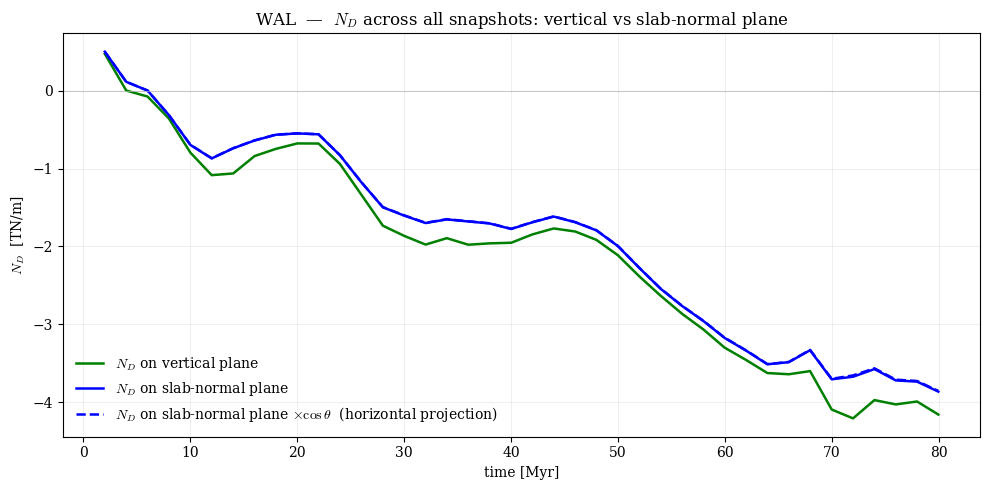

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_yr_arr/1e6, Fd_vert_arr    * 1e-12, color='green',     ls='-',  lw=1.8,
        label=r'$N_D$ on vertical plane')
ax.plot(t_yr_arr/1e6, Fd_slabn_arr   * 1e-12, color='blue',  ls='-',  lw=1.8,
        label=r'$N_D$ on slab-normal plane')
ax.plot(t_yr_arr/1e6, Fd_slabn_h_arr * 1e-12, color='blue',  ls='--', lw=1.8,
        label=r'$N_D$ on slab-normal plane $\times\cos\theta$  (horizontal projection)')
ax.axhline(0, color='0.7', lw=0.5)
ax.set_xlabel('time [Myr]')
ax.set_ylabel(r'$N_D$  [TN/m]')
ax.set_title(f'{MODEL_KEY}  —  $N_D$ across all snapshots: vertical vs slab-normal plane')
ax.legend(loc='best', frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()

figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'slab_normal_FD_evolution_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)
plt.show()


## 12. $N_D$ along the slab-top SP boundary

§8 evaluates $N_D$ on a single slab-normal plane through the trench. This section extends that to a *series* of slab-normal planes along the slab top, walking from the trailing-plate lithosphere through the trench bend and down into the deep slab.

**Pipeline.** Trace the contour of the subducting-plate material fraction at $\mathrm{SP}=0.5$ — the actual slab-top boundary, including the trailing-plate continuation just below the weak layer. Walk the polyline in both directions from a seed near the trench, smooth it with a Gaussian filter, fit a cubic spline, sample uniformly in arc length. At each evaluation point compute the local dip from the spline tangent, build a slab-normal line, sample stresses, mask, integrate.

**Outputs.**
- $N_D$ on each slab-normal plane
- $N_D\cos\theta$ — horizontal projection
- $N_D\sin\theta$ — vertical projection (sign-corrected to "downward = positive" in plotting)
- local dip $\theta$ from the spline tangent

all as functions of arc length from the trench and depth of the eval point.

The geometry-only quantity used here is the SP-boundary contour. Temperature appears only inside the mask (see "Masking strategy" below); it never enters the geometry calculation.

In [12]:
# N_D along the slab-top SP boundary — full pipeline (sanity viz + N_D plots).
#
# Drop into a fresh cell in fluidity_slab_normal_FD.ipynb after §6.  Requires:
#   x, z, T, txx, tzz, txz             (from §4 load cell)
#   x_trench, tindx                        (from §5 trench picker)
#   vtk_data, grid, interp, nx_pv,
#   nz_pv, valid                       (still in scope from §4)
#   MIRROR_X, SEAWARD_SIGN, MODEL_KEY, t_yr, DX

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, RegularGridInterpolator
from scipy.ndimage import gaussian_filter1d
import contourpy

# ---- 0. Extract SP material fraction --------------------------------------
vtk_data.point_data['sp'] = vtk_data['NormalSP::MaterialVolumeFraction']
interp_sp = grid.sample(vtk_data)
SP = interp_sp['sp'].reshape((nx_pv, nz_pv), order='F')
SP[~valid] = np.nan
SP = SP.T   # (z, x)
if MIRROR_X:
    SP = np.flip(SP, axis=1)

# ---- 1. Parameters ---------------------------------------------------------
SP_LEVEL                = 0.5
SEED_X_M                = x_trench
SEED_Z_M                = 5_000.0       # near trench, slab-top branch (just below weak layer)
EVAL_STEP_KM            = 10.0           # arc-length spacing of eval points
MAX_DEPTH_KM            = 400.0
SMOOTH_SIGMA_PTS        = 20            # Gaussian smoothing on the polyline
TURNING_POINT_TOL_M     = 5_000.0
DECOUPLING_DEPTH_KM     = 125.0 

EXTEND_BACK_KM          = 400.0         # how far to follow the polyline back along the trailing plate

SLAB_NORMAL_UP_KM       = 20.0          # extend ABOVE the SP boundary (into asthenosphere/OP/weak-layer)
SLAB_NORMAL_DOWN_KM     = 120.0         # extend BELOW (into slab interior)
DS_PATH_M               = 1_000.0

SP_THRESHOLD_MASK       = 0.5
T_MAX_K                 = 1273.0

# ---- 2. Trace the SP=0.5 boundary -----------------------------------------
gen = contourpy.contour_generator(x=x, y=z, z=SP)
segments = gen.lines(SP_LEVEL)

flat_pts  = np.vstack(segments)
seg_owner = np.concatenate([np.full(len(s), i) for i, s in enumerate(segments)])
seed = np.array([SEED_X_M, SEED_Z_M])
nearest_flat = int(np.argmin(np.linalg.norm(flat_pts - seed, axis=1)))
chosen_full = segments[seg_owner[nearest_flat]]

# ---- 3. Walk the polyline in BOTH directions from the seed ----------------
# The slab-top SP boundary is one continuous polyline that runs from far in
# the trailing plate (horizontal at z ~ 5 km, just under the weak layer),
# bends through the trench, and descends along the slab top.  Walking from
# the seed in both directions traces the actual contour — no synthetic z=0
# extension required.
seed_idx = int(np.argmin(np.linalg.norm(chosen_full - seed, axis=1)))
test_step = min(20, len(chosen_full) - seed_idx - 1, seed_idx)
fwd_dz = chosen_full[min(seed_idx + test_step, len(chosen_full)-1), 1] - chosen_full[seed_idx, 1]
bwd_dz = chosen_full[max(seed_idx - test_step, 0), 1] - chosen_full[seed_idx, 1]

if fwd_dz > bwd_dz:
    slab_side  = chosen_full[seed_idx:]
    plate_side = chosen_full[:seed_idx][::-1]   # reversed: from seed -> outward
else:
    slab_side  = chosen_full[:seed_idx + 1][::-1]
    plate_side = chosen_full[seed_idx + 1:]

# Slab side: turning-point + hard depth cap
z_running = slab_side[:, 1]
cummax    = np.maximum.accumulate(z_running)
turning   = np.where(z_running < cummax - TURNING_POINT_TOL_M)[0]
stop_idx  = turning[0] if len(turning) > 0 else len(slab_side)
slab_side = slab_side[:stop_idx]
slab_side = slab_side[slab_side[:, 1] < MAX_DEPTH_KM * 1_000.0]

# Plate side: limit by horizontal distance from trench
if EXTEND_BACK_KM > 0 and len(plate_side) > 0:
    dist_from_trench = np.abs(plate_side[:, 0] - x_trench)
    plate_side = plate_side[dist_from_trench < EXTEND_BACK_KM * 1_000.0]
else:
    plate_side = plate_side[:0]

# Combine: re-reverse plate_side so it runs far-back -> seed, then slab_side
walk = np.vstack([plate_side[::-1], slab_side])

print(f'walked: plate_side={len(plate_side)} pts, slab_side={len(slab_side)} pts, '
      f'combined={len(walk)} pts')

# ---- 4. Smooth the combined polyline --------------------------------------
slab_top = walk.copy()
slab_top[:, 0] = gaussian_filter1d(slab_top[:, 0], sigma=SMOOTH_SIGMA_PTS)
slab_top[:, 1] = gaussian_filter1d(slab_top[:, 1], sigma=SMOOTH_SIGMA_PTS)
print(f'depth range: {slab_top[0,1]/1e3:.1f} -> {slab_top[-1,1]/1e3:.1f} km')

# ---- 5. Reparametrise by arc length, sample uniformly ---------------------
ds_seg = np.linalg.norm(np.diff(slab_top, axis=0), axis=1)
s_raw  = np.concatenate([[0.0], np.cumsum(ds_seg)])
spline_x = CubicSpline(s_raw, slab_top[:, 0])
spline_z = CubicSpline(s_raw, slab_top[:, 1])

s_eval   = np.arange(0, s_raw[-1], EVAL_STEP_KM * 1_000.0)
x_eval   = spline_x(s_eval)
z_eval   = spline_z(s_eval)
dxds     = spline_x(s_eval, 1)
dzds     = spline_z(s_eval, 1)

# Anchor s_arc = 0 at the trench (closest eval point to (x_trench, 0))
i_trench = int(np.argmin(np.hypot(x_eval - x_trench, z_eval)))
s_arc    = s_eval - s_eval[i_trench]

# Tangent + slab-normal direction.
# In the combined walk, tx < 0 throughout (we walk leftward toward & through
# the trench in mirror frame).  The CW perpendicular (+tz, -tx) is then
# always pointing into the SP material (downward in trailing plate, into
# slab in slab portion).
ds_norm  = np.hypot(dxds, dzds)
tx, tz   = dxds / ds_norm, dzds / ds_norm
nx_hat   = +tz
nz_hat   = -tx

# Dip = arctan(dz/dx) — matches the existing trench code's convention.
dip_eval = np.arctan(dzds / np.where(dxds == 0, 1e-12, dxds))

# ---- 6. Build asymmetric slab-normal lines --------------------------------
n_up   = int(SLAB_NORMAL_UP_KM   * 1_000.0 / DS_PATH_M)
n_down = int(SLAB_NORMAL_DOWN_KM * 1_000.0 / DS_PATH_M)
s_local = np.arange(-n_up, n_down + 1) * DS_PATH_M

X_lines = x_eval[:, None] + s_local[None, :] * nx_hat[:, None]
Z_lines = z_eval[:, None] + s_local[None, :] * nz_hat[:, None]

# ---- 7. Sample stresses + masks; integrate N_D ----------------------------
ftxx = RegularGridInterpolator((z, x), txx, bounds_error=False, fill_value=np.nan)
ftzz = RegularGridInterpolator((z, x), tzz, bounds_error=False, fill_value=np.nan)
ftxz = RegularGridInterpolator((z, x), txz, bounds_error=False, fill_value=np.nan)
fT   = RegularGridInterpolator((z, x), T,   bounds_error=False, fill_value=np.nan)
fSP  = RegularGridInterpolator((z, x), SP,  bounds_error=False, fill_value=0.0)

Fd_arr   = np.full(len(s_eval), np.nan)
Fd_h_arr = np.full(len(s_eval), np.nan)
Fd_v_arr = np.full(len(s_eval), np.nan)


for i in range(len(s_eval)):
    pts = np.column_stack([Z_lines[i], X_lines[i]])
    txx_p = ftxx(pts); tzz_p = ftzz(pts); txz_p = ftxz(pts)
    T_p   = fT(pts);   SP_p  = fSP(pts)

    two_th   = 2 * dip_eval[i]
    diff_rot = (txx_p - tzz_p) * np.cos(two_th) + 2 * txz_p * np.sin(two_th)
    #keep     = (SP_p > SP_THRESHOLD_MASK) & (T_p < T_MAX_K) & np.isfinite(diff_rot)
    z_along      = pts[:, 0]                         # depth of each sample on the line                                                                                    
    shallow      = z_along < DECOUPLING_DEPTH_KM * 1_000.0                                                                                                                 
    mask_shallow = (SP_p > SP_THRESHOLD_MASK) & (T_p < T_MAX_K)                                                                                                            
    mask_deep    = (T_p < T_MAX_K)                                                                                                                                         
    keep = np.where(shallow, mask_shallow, mask_deep) & np.isfinite(diff_rot) 

    if keep.sum() < 2:
        continue
    Fd_arr[i]   = np.trapz(diff_rot[keep], s_local[keep])
    Fd_h_arr[i] = Fd_arr[i] * np.cos(dip_eval[i])
    Fd_v_arr[i] = Fd_arr[i] * np.sin(dip_eval[i])

print(f'N_D computed at {np.isfinite(Fd_arr).sum()}/{len(s_eval)} eval points')




walked: plate_side=479 pts, slab_side=1039 pts, combined=1518 pts
depth range: 7.4 -> 392.0 km
N_D computed at 117/117 eval points


### Masking strategy

The slab-normal line crosses both slab and non-slab cells; the mask decides which contribute to the integral.

Two competing definitions of "slab":

- **SP-fraction mask** (`SP > SP_THRESHOLD_MASK`): keep only cells originally tagged as subducting-plate material. Tight and conservative. **Problem:** as the slab descends it cools the surrounding mantle into a thermal boundary layer that is mechanically part of the slab — but the halo carries no SP tag, so it gets excluded.

- **Temperature mask** (`T < T_MAX_K`): keep all cool material regardless of provenance. Includes the halo. **Problem:** in the trailing-plate region the mantle just below the lithosphere is asthenosphere (warm enough that the T mask correctly excludes it), but T-only would also fold in any unrelated cool patches anywhere in the domain.

The implementation here splits at `DECOUPLING_DEPTH_KM`:

| depth of sample | mask |
|---|---|
| `z < DECOUPLING_DEPTH_KM` | `(SP > SP_THRESHOLD_MASK) & (T < T_MAX_K)` |
| `z ≥ DECOUPLING_DEPTH_KM` | `T < T_MAX_K` |

Above the threshold the SP mask is strict and the halo is thin; below it the SP mask would systematically under-count the slab and the temperature mask alone is appropriate.

The mask is applied **per-sample** along each slab-normal line — a single line crossing the threshold uses the appropriate rule on each half. Same logic is used for the masked pcolormesh backgrounds in the sanity-check viz, so what you see coloured is what gets integrated.

Sharp transition: if $N_D(s_\mathrm{arc})$ shows a visible step around the eval point with $z_\mathrm{eval} \approx$ `DECOUPLING_DEPTH_KM`, refine by either (a) softening the transition with a depth-blended mask over a 20–30 km window, or (b) splitting `T_MAX_K` into shallow/deep variants for finer tuning.

In [13]:
2900 - 2720

180

### Geometry sanity check

Background: $\sigma_{xx} - \sigma_{zz}$ with the same per-sample mask the N_D integration uses — coloured cells are exactly the cells that contribute to the integral. Overlays:

- All SP=0.5 polylines (gray) — for context
- The chosen polyline post-truncation (gold, raw)
- The smoothed tracker (magenta) — what the N_D integration actually uses
- All slab-normal evaluation lines (white)
- Trench marker (white circle)

Visual sanity test: do the slab-normal lines bracket the slab body without drifting off into asthenosphere or the upper plate?

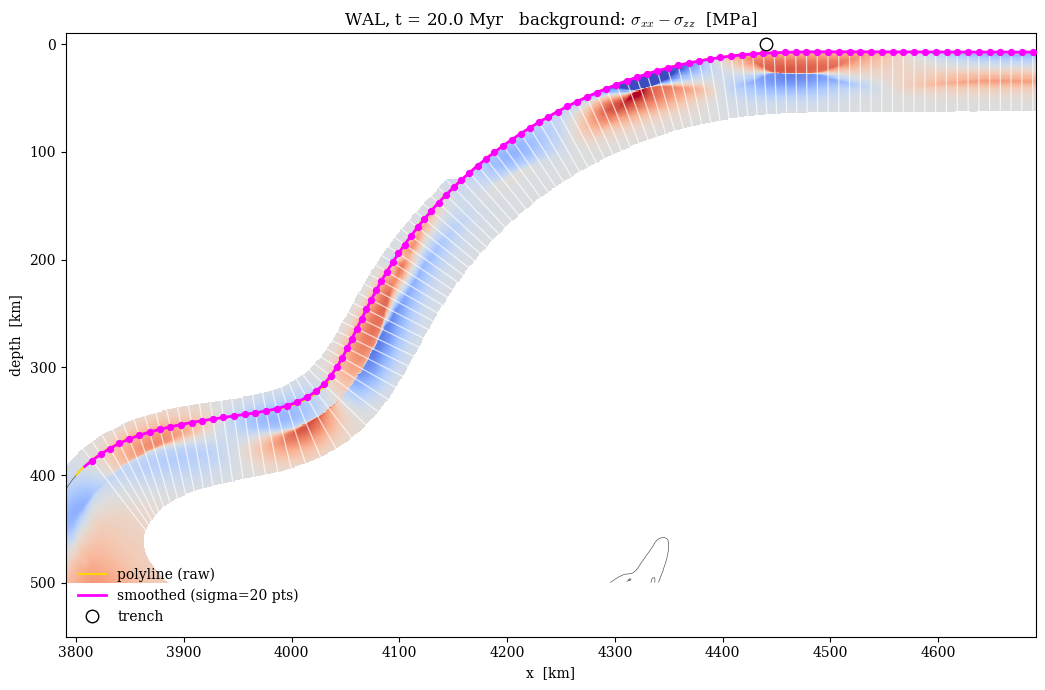

In [14]:
# ---- 8. Sanity-check figure (geometry) ------------------------------------
fig1, ax = plt.subplots(figsize=(13, 7))
#ax.pcolormesh(x*1e-3, z*1e-3, (txx - tzz) * 1e-6,
#              cmap='coolwarm', shading='auto', vmin=-300, vmax=+300)

#mask_grid = (SP > SP_THRESHOLD_MASK) & (T < T_MAX_K)  
shallow_grid = z[:, None] < DECOUPLING_DEPTH_KM * 1_000.0   # broadcasts to (nz, nx)                                                                                   
mask_grid = np.where(shallow_grid,                                                                                                                                     
                       (SP > SP_THRESHOLD_MASK) & (T < T_MAX_K),                                                                                                         
                       (T < T_MAX_K))   
diff_masked = np.where(mask_grid, (txx - tzz) * 1e-6, np.nan)
ax.pcolormesh(x*1e-3, z*1e-3, diff_masked,                                                                                                                             
                cmap='coolwarm', shading='auto', vmin=-300, vmax=+300)


for seg in segments:
    ax.plot(seg[:, 0]*1e-3, seg[:, 1]*1e-3, color='0.35', lw=0.5)
ax.plot(walk[:, 0]*1e-3, walk[:, 1]*1e-3, color='gold', lw=1.4,
        label='polyline (raw)')
ax.plot(slab_top[:, 0]*1e-3, slab_top[:, 1]*1e-3, color='magenta', lw=2.0,
        label=f'smoothed (sigma={SMOOTH_SIGMA_PTS} pts)')
for i in range(len(s_eval)):
    ax.plot(X_lines[i]*1e-3, Z_lines[i]*1e-3, color='white', lw=0.9, alpha=0.7)
ax.scatter(x_eval*1e-3, z_eval*1e-3, color='magenta', s=18, zorder=5)
ax.plot(x_trench*1e-3, 0, 'wo', mec='k', ms=9, zorder=6, label='trench')
ax.invert_yaxis()
ax.set_xlim((x_trench - 650e3)*1e-3, (x_trench + 250e3)*1e-3)
ax.set_ylim(MAX_DEPTH_KM + 150, -10)
ax.set_aspect('equal')
ax.set_xlabel('x  [km]')
ax.set_ylabel('depth  [km]')
ax.set_title(f'{MODEL_KEY}, t = {t_yr/1e6:.1f} Myr   '
             r'background: $\sigma_{xx} - \sigma_{zz}$  [MPa]')
ax.legend(loc='lower left', frameon=False, fontsize=10)
fig1.tight_layout()



### $N_D$ along the slab top

Two plots:

- **Left:** $N_D$ vs arc length from the trench, $s = 0$ anchored at the trench. Negative $s$ = trailing plate; positive $s$ = into the slab. Both the slab-normal $N_D$ and its vertical projection $N_D\sin\theta$ shown (the latter sign-corrected to "downward = positive" in the plot).
- **Right:** the same quantities vs depth of the eval point.

$N_D\sin\theta$ is small in the trailing-plate region (slab is near-horizontal so $\theta \approx 0$) and grows toward $|N_D|$ as the slab steepens — pure projection geometry.

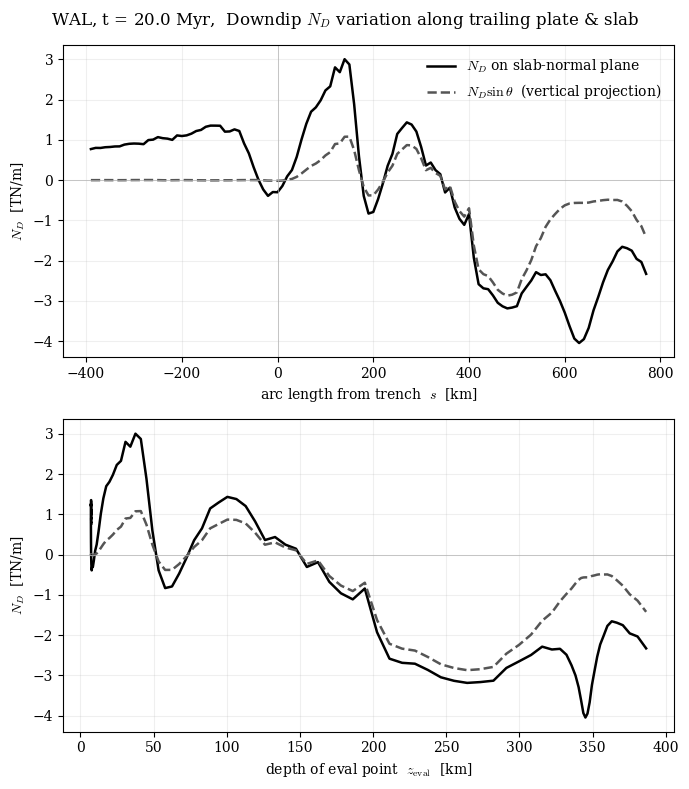

In [15]:
# ---- 9. N_D plots ---------------------------------------------------------
fig2, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(7, 8))

ax_a.plot(s_arc*1e-3, Fd_arr   * 1e-12, color='k',    ls='-',  lw=1.8,
          label=r'$N_D$ on slab-normal plane')
ax_a.plot(s_arc*1e-3, -Fd_v_arr * 1e-12, color='#555', ls='--', lw=1.8,
          label=r'$N_D \sin\theta$  (vertical projection)')
ax_a.axvline(0, color='0.7', lw=0.5)
ax_a.axhline(0, color='0.7', lw=0.5)
ax_a.set_xlabel(r'arc length from trench  $s$  [km]')
ax_a.set_ylabel(r'$N_D$  [TN/m]')
ax_a.legend(loc='best', frameon=False)
ax_a.grid(alpha=0.2)

ax_b.plot(z_eval*1e-3, Fd_arr   * 1e-12, color='k',    ls='-',  lw=1.8,
          label=r'$N_D$ on slab-normal plane')
ax_b.plot(z_eval*1e-3, -Fd_v_arr * 1e-12, color='#555', ls='--', lw=1.8,
          label=r'$N_D \sin\theta$')
ax_b.axhline(0, color='0.7', lw=0.5)
ax_b.set_xlabel(r'depth of eval point  $z_\mathrm{eval}$  [km]')
ax_b.set_ylabel(r'$N_D$  [TN/m]')
#ax_b.legend(loc='best', frameon=False)
ax_b.grid(alpha=0.2)

fig2.suptitle(f'{MODEL_KEY}, t = {t_yr/1e6:.1f} Myr,  '
              r'Downdip $N_D$ variation along trailing plate & slab')
fig2.tight_layout()

fig2.savefig(figures_dir / f'Fd_along_slabtop_{MODEL_KEY}_f{TIMESTEP_INDEX}.png',                                                                                      
               bbox_inches='tight', dpi=200) 

plt.show()

### Rotated differential stress on the full grid

Diagnostic visualisation. The rotation angle $\theta$ is computed at every grid cell by KDTree-querying its nearest sample on a dense parametrisation of the SP-boundary spline — same dip values the per-line N_D integration uses, just extended to the full grid. The rotated quantity

$$\sigma_{\xi\xi} - \sigma_{\eta\eta} \;=\; (\sigma_{xx}-\sigma_{zz})\cos 2\theta + 2\tau_{zx}\sin 2\theta$$

is then masked by the same depth-decoupled mask and rendered. What you see in slab-frame coordinates is exactly what the N_D integration is summing along each slab-normal line.

In [16]:
# Rotated differential stress on the full grid, masked + plotted.
#
# Drops into a fresh cell AFTER the slab-orthogonal-lines script, so it can
# reuse: x, z, X, Z, txx, tzz, txz, T, SP, spline_x, spline_z, s_raw,
# DS_PATH_M, MAX_DEPTH_KM, SP_THRESHOLD_MASK, T_MAX_K, slab_top, segments,
# walk, X_lines, Z_lines, x_eval, z_eval, x_trench, MODEL_KEY, t_yr.

from scipy.spatial import cKDTree

# ---- 1. Dense-sample the slab-top spline ---------------------------------
s_dense = np.arange(0.0, s_raw[-1], DS_PATH_M)
x_dense = spline_x(s_dense)
z_dense = spline_z(s_dense)
dx_d    = spline_x(s_dense, 1)
dz_d    = spline_z(s_dense, 1)
dip_dense = np.arctan(dz_d / np.where(dx_d == 0, 1e-12, dx_d))

# ---- 2. Nearest-spline-sample dip per grid point -------------------------
tree = cKDTree(np.column_stack([x_dense, z_dense]))
_, ix_near = tree.query(np.column_stack([X.ravel(), Z.ravel()]))
dip_grid = dip_dense[ix_near].reshape(X.shape)

# X, Z from §4 are oriented (x, z); txx etc. are (z, x).  Transpose to match.
#dip_grid = dip_grid.T

# ---- 3. Rotated differential stress on the grid --------------------------
two_th = 2 * dip_grid
diff_rot_grid = (txx - tzz) * np.cos(two_th) + 2 * txz * np.sin(two_th)

# ---- 4. Mask (same as the N_D integration) -------------------------------
#mask_grid = (SP > SP_THRESHOLD_MASK) & (T < T_MAX_K)

shallow_grid = z[:, None] < DECOUPLING_DEPTH_KM * 1_000.0   # broadcasts to (nz, nx)                                                                                   
mask_grid = np.where(shallow_grid,                                                                                                                                     
                       (SP > SP_THRESHOLD_MASK) & (T < T_MAX_K),                                                                                                         
                       (T < T_MAX_K))   

diff_rot_masked = np.where(mask_grid, diff_rot_grid * 1e-6, np.nan)



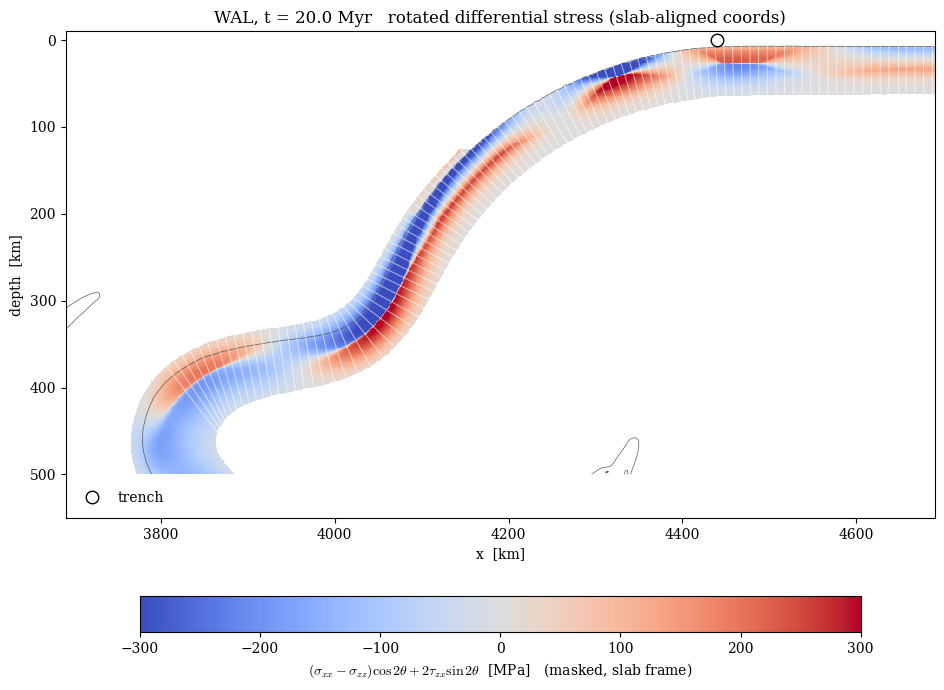

In [17]:

# ---- 5. Plot -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 7))

im = ax.pcolormesh(x*1e-3, z*1e-3, diff_rot_masked,
                   cmap='coolwarm', shading='auto', vmin=-300, vmax=+300)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal',
                    fraction=0.06, pad=0.13,
                    label=r'$(\sigma_{xx}-\sigma_{zz})\cos 2\theta + 2\tau_{zx}\sin 2\theta$  [MPa]   '
                          '(masked, slab frame)')

# SP=0.5 contour for reference
for seg in segments:
    ax.plot(seg[:, 0]*1e-3, seg[:, 1]*1e-3, color='0.35', lw=0.5)
#ax.plot(slab_top[:, 0]*1e-3, slab_top[:, 1]*1e-3, color='magenta', lw=2.0,
#        label='SP-boundary tracker (smoothed)')

# Slab-normal lines + eval points
for i in range(len(x_eval)):
    ax.plot(X_lines[i]*1e-3, Z_lines[i]*1e-3, color='white', lw=0.7, alpha=0.6)
#ax.scatter(x_eval*1e-3, z_eval*1e-3, color='magenta', s=14, zorder=5)

ax.plot(x_trench*1e-3, 0, 'wo', mec='k', ms=9, zorder=6, label='trench')

ax.invert_yaxis()
ax.set_xlim((x_trench - 750e3)*1e-3, (x_trench + 250e3)*1e-3)
ax.set_ylim(MAX_DEPTH_KM + 150, -10)
ax.set_aspect('equal')
ax.set_xlabel('x  [km]')
ax.set_ylabel('depth  [km]')
ax.set_title(f'{MODEL_KEY}, t = {t_yr/1e6:.1f} Myr   '
             'rotated differential stress (slab-aligned coords)')
ax.legend(loc='lower left', frameon=False, fontsize=10)
fig.tight_layout()
fig.savefig(figures_dir / f'rotated_diff_stress_{MODEL_KEY}_f{TIMESTEP_INDEX}.png',                                                                                    
              bbox_inches='tight', dpi=200)
plt.show()